# GraphRAG Lab: Knowledge Graph-Powered Retrieval with Neo4j

Build a GraphRAG system that extracts entities and relationships from company reports,
stores them in a Neo4j knowledge graph, and answers questions using both **graph retrieval** (Cypher)
and **vector search** (semantic similarity).

**What you'll learn:**
- Extract entities & relationships from text using LLM (`LLMGraphTransformer`)
- Build a knowledge graph in Neo4j
- Query relationships with Cypher (GraphRAG)
- Query semantics with vector search (Neo4j vector index)
- Build a LangGraph agent that routes between graph and vector retrieval
- Evaluate GraphRAG vs. vector-only RAG

**Data:** Three fictional company annual reports (Aurora Holdings, Beacon Retail, Crest Manufacturing)
with rich inter-company relationships, board members, strategic decisions, and financial results.

In [ ]:
%uv add langchain langchain-openai langchain-neo4j langchain-experimental langchain-community langchain-text-splitters langgraph neo4j python-dotenv

In [1]:
import os
import logging
from dotenv import load_dotenv

load_dotenv("../.env")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s - %(message)s",
)
logger = logging.getLogger("graph_rag_lab")

logger.info("OpenAI API key configured: %s", "Yes" if os.getenv("OPENAI_API_KEY") else "No")
logger.info("Neo4j URI configured: %s", "Yes" if os.getenv("NEO4J_URI") else "No")

2026-04-05 22:24:56,540 [INFO] graph_rag_lab - OpenAI API key configured: Yes
2026-04-05 22:24:56,541 [INFO] graph_rag_lab - Neo4j URI configured: Yes


## Step 1: Load the Documents

Load three company annual reports that contain rich entity relationships.

In [2]:
from langchain_core.documents import Document

doc_dir = "./documents"
documents = []
for filename in sorted(os.listdir(doc_dir)):
    if filename.endswith(".txt"):
        filepath = os.path.join(doc_dir, filename)
        with open(filepath, "r") as f:
            text = f.read()
        documents.append(Document(page_content=text, metadata={"source": filename}))
        logger.info("Loaded %s: %d characters", filename, len(text))

logger.info("Total documents loaded: %d", len(documents))

2026-04-05 22:24:58,750 [INFO] graph_rag_lab - Loaded aura_holding.txt: 7849 characters
2026-04-05 22:24:58,751 [INFO] graph_rag_lab - Loaded beacon_retail.txt: 6982 characters
2026-04-05 22:24:58,751 [INFO] graph_rag_lab - Loaded crest.txt: 6932 characters
2026-04-05 22:24:58,751 [INFO] graph_rag_lab - Total documents loaded: 3


## Step 2: Extract Entities & Relationships with LLM

Use `LLMGraphTransformer` to extract structured entities and relationships from the text.
We constrain extraction to focus on:
- **Company ↔ Company** (acquisitions, partnerships, competition)
- **Person → Company** (board roles, leadership)
- **Decision → Result** (strategic actions and outcomes)
- **Person ↔ Person** (implicit via shared companies)

In [10]:
from langchain_openai import ChatOpenAI
from langchain_experimental.graph_transformers import LLMGraphTransformer

In [ ]:


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

llm_transformer = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=["Company", "Person", "Decision", "Result", "Technology", "Market", "Product"],
    allowed_relationships=[
        "ACQUIRED",
        "SUBSIDIARY_OF",
        "CHAIRMAN_OF",
        "CEO_OF",
        "CFO_OF",
        "INDEPENDENT_DIRECTOR_OF",
        "MADE_DECISION",
        "RESULTED_IN",
        "OPERATES_IN",
        "HEADQUARTERED_IN",
        "INVESTED_IN",
        "PARTNER_WITH",
        "SUPPLIES_TO",
    ],
    node_properties=["description"],
    # prompt=... TODO: add your own prompt to get better results
)

logger.info("Extracting entities and relationships from %d documents...", len(documents))
graph_documents = llm_transformer.convert_to_graph_documents(documents)

for doc in graph_documents:
    source = doc.source.metadata.get("source", "unknown")
    logger.info("Source: %s | Nodes: %d | Relationships: %d", source, len(doc.nodes), len(doc.relationships))

2026-04-05 22:37:26,457 [INFO] graph_rag_lab - Extracting entities and relationships from 3 documents...
2026-04-05 22:37:42,851 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 22:37:55,340 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 22:38:07,974 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 22:38:07,979 [INFO] graph_rag_lab - Source: aura_holding.txt | Nodes: 15 | Relationships: 17
2026-04-05 22:38:07,979 [INFO] graph_rag_lab - Source: beacon_retail.txt | Nodes: 11 | Relationships: 13
2026-04-05 22:38:07,980 [INFO] graph_rag_lab - Source: crest.txt | Nodes: 14 | Relationships: 13


In [4]:
for doc in graph_documents:
    source = doc.source.metadata.get("source", "unknown")
    print(f"\n{'=' * 60}")
    print(f"Source: {source}")
    print(f"{'=' * 60}")

    print("\nNodes:")
    for node in doc.nodes:
        desc = node.properties.get("description", "")
        desc_str = f" — {desc}" if desc else ""
        print(f"  [{node.type}] {node.id}{desc_str}")

    print("\nRelationships:")
    for rel in doc.relationships:
        print(f"  ({rel.source.id}) -[{rel.type}]-> ({rel.target.id})")


Source: aura_holding.txt

Nodes:
  [Company] Aurora Holdings
  [Person] Nguyen Minh Quan
  [Person] Tran Thi Lan Anh
  [Person] Le Hoang Phuc
  [Person] David Chen
  [Person] Sarah Lim
  [Company] Beacon Retail Group
  [Market] Southeast Asia
  [Market] Indonesia
  [Market] Thailand
  [Decision] Fiscal Year 2025
  [Decision] Q1
  [Decision] Q2
  [Decision] Q3
  [Decision] Q4

Relationships:
  (Aurora Holdings) -[OPERATES_IN]-> (Southeast Asia)
  (Aurora Holdings) -[ACQUIRED]-> (Beacon Retail Group)
  (Aurora Holdings) -[MADE_DECISION]-> (Fiscal Year 2025)
  (Aurora Holdings) -[MADE_DECISION]-> (Q1)
  (Aurora Holdings) -[MADE_DECISION]-> (Q2)
  (Aurora Holdings) -[MADE_DECISION]-> (Q3)
  (Aurora Holdings) -[MADE_DECISION]-> (Q4)
  (Nguyen Minh Quan) -[CHAIRMAN_OF]-> (Aurora Holdings)
  (Tran Thi Lan Anh) -[CEO_OF]-> (Aurora Holdings)
  (Le Hoang Phuc) -[CFO_OF]-> (Aurora Holdings)
  (David Chen) -[INDEPENDENT_DIRECTOR_OF]-> (Aurora Holdings)
  (Sarah Lim) -[INDEPENDENT_DIRECTOR_OF]-> (

## Step 3: Store Knowledge Graph in Neo4j

Connect to Neo4j and persist the extracted graph documents.
Each node and relationship from the LLM extraction becomes a real graph element in the database.

In [25]:
NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")

In [ ]:
from langchain_neo4j import Neo4jGraph
graph = Neo4jGraph(url=NEO4J_URI, username=NEO4J_USERNAME, password=NEO4J_PASSWORD, database="NEO4J_DATABASE")
logger.info("Connected to Neo4j at %s", NEO4J_URI)

2026-04-05 22:38:20,093 [INFO] graph_rag_lab - Connected to Neo4j at neo4j+s://b5595827.databases.neo4j.io


In [27]:
graph.query("MATCH (n) DETACH DELETE n")
logger.info("Cleared existing graph data for clean lab run")

graph.add_graph_documents(graph_documents, baseEntityLabel=True, include_source=True)
logger.info("Stored %d graph documents in Neo4j", len(graph_documents))

graph.refresh_schema()
print("\nGraph Schema:")
print(graph.schema)

2026-04-05 22:38:25,018 [INFO] graph_rag_lab - Cleared existing graph data for clean lab run
2026-04-05 22:38:26,003 [INFO] graph_rag_lab - Stored 3 graph documents in Neo4j



Graph Schema:
Node properties:
Document {id: STRING, text: STRING, source: STRING}
Company {id: STRING}
Person {id: STRING}
Market {id: STRING}
Decision {id: STRING}
Technology {id: STRING}
Result {id: STRING}
Relationship properties:

The relationships:
(:Document)-[:MENTIONS]->(:Company)
(:Document)-[:MENTIONS]->(:Person)
(:Document)-[:MENTIONS]->(:Market)
(:Document)-[:MENTIONS]->(:Decision)
(:Document)-[:MENTIONS]->(:Technology)
(:Document)-[:MENTIONS]->(:Result)
(:Company)-[:OPERATES_IN]->(:Market)
(:Company)-[:ACQUIRED]->(:Company)
(:Company)-[:MADE_DECISION]->(:Decision)
(:Company)-[:CHAIRMAN_OF]->(:Person)
(:Company)-[:CEO_OF]->(:Person)
(:Company)-[:CFO_OF]->(:Person)
(:Company)-[:INDEPENDENT_DIRECTOR_OF]->(:Person)
(:Company)-[:RESULTED_IN]->(:Result)
(:Company)-[:HEADQUARTERED_IN]->(:Market)
(:Company)-[:INVESTED_IN]->(:Technology)
(:Person)-[:CHAIRMAN_OF]->(:Company)
(:Person)-[:CEO_OF]->(:Company)
(:Person)-[:CFO_OF]->(:Company)
(:Person)-[:INDEPENDENT_DIRECTOR_OF]->(:Com

In [28]:
node_counts = graph.query("MATCH (n) RETURN labels(n) AS label, count(*) AS count")
print("Node counts:")
for r in node_counts:
    print(f"  {r['label']}: {r['count']}")

rel_counts = graph.query(
    "MATCH ()-[r]->() RETURN type(r) AS type, count(*) AS count ORDER BY count DESC"
)
print("\nRelationship counts:")
for r in rel_counts:
    print(f"  {r['type']}: {r['count']}")

Node counts:
  ['Document']: 3
  ['__Entity__', 'Company']: 3
  ['__Entity__', 'Person']: 14
  ['__Entity__', 'Market']: 7
  ['__Entity__', 'Decision']: 7
  ['__Entity__', 'Technology']: 3
  ['__Entity__', 'Result']: 1

Relationship counts:
  MENTIONS: 40
  MADE_DECISION: 11
  RESULTED_IN: 10
  INDEPENDENT_DIRECTOR_OF: 5
  OPERATES_IN: 3
  CHAIRMAN_OF: 3
  CEO_OF: 3
  CFO_OF: 3
  INVESTED_IN: 3
  ACQUIRED: 1
  HEADQUARTERED_IN: 1


In [29]:
print("Company-Company Relationships:")
company_rels = graph.query(
    "MATCH (c1:Company)-[r]->(c2:Company) "
    "RETURN c1.id AS from_company, type(r) AS relationship, c2.id AS to_company"
)
for r in company_rels:
    print(f"  {r['from_company']} --[{r['relationship']}]--> {r['to_company']}")

print("\nPeople-Company Relationships:")
people_rels = graph.query(
    "MATCH (p:Person)-[r]->(c:Company) "
    "RETURN p.id AS person, type(r) AS role, c.id AS company"
)
for r in people_rels:
    print(f"  {r['person']} --[{r['role']}]--> {r['company']}")

print("\nDecision-Result Relationships:")
decision_rels = graph.query(
    "MATCH (d:Decision)-[r]->(res:Result) "
    "RETURN d.id AS decision, type(r) AS rel, res.id AS result"
)
for r in decision_rels:
    print(f"  {r['decision']} --[{r['rel']}]--> {r['result']}")
if not decision_rels:
    decision_rels_alt = graph.query(
        "MATCH (d:Decision)-[r]-(other) "
        "RETURN d.id AS decision, type(r) AS rel, labels(other) AS other_label, other.id AS other_id"
    )
    for r in decision_rels_alt:
        print(f"  {r['decision']} --[{r['rel']}]--> {r['other_label']} {r['other_id']}")

Company-Company Relationships:
  Aurora Holdings --[ACQUIRED]--> Beacon Retail Group

People-Company Relationships:
  Nguyen Minh Quan --[CHAIRMAN_OF]--> Aurora Holdings
  Tran Thi Lan Anh --[CEO_OF]--> Aurora Holdings
  Le Hoang Phuc --[CFO_OF]--> Aurora Holdings
  David Chen --[INDEPENDENT_DIRECTOR_OF]--> Aurora Holdings
  Sarah Lim --[INDEPENDENT_DIRECTOR_OF]--> Aurora Holdings

Decision-Result Relationships:
  Fiscal Year 2025 --[MENTIONS]--> ['Document'] 50ece29b1e4d43ca5c644df125a79635
  Fiscal Year 2025 --[MADE_DECISION]--> ['__Entity__', 'Company'] Aurora Holdings
  Q1 --[MENTIONS]--> ['Document'] 50ece29b1e4d43ca5c644df125a79635
  Q1 --[MENTIONS]--> ['Document'] 8ac026ced34a544cbb99fd52c9cbed4e
  Q1 --[MADE_DECISION]--> ['__Entity__', 'Company'] Aurora Holdings
  Q1 --[MADE_DECISION]--> ['__Entity__', 'Company'] Beacon Retail Group
  Q1 --[RESULTED_IN]--> ['__Entity__', 'Market'] Indonesia
  Q1 --[RESULTED_IN]--> ['__Entity__', 'Market'] Thailand
  Q1 --[RESULTED_IN]--> ['__En

## Step 4: Create Vector Index for Semantic Search

Split the original documents into smaller chunks using `RecursiveCharacterTextSplitter`,
then embed and store them as separate vector-indexed nodes via `Neo4jVector.from_documents()`.
This gives fine-grained control over **chunk size** and **embedding model**, producing better
vector retrieval for longer documents.

In [49]:
from langchain_openai import OpenAIEmbeddings
from langchain_neo4j import Neo4jVector
from langchain_text_splitters import RecursiveCharacterTextSplitter
import uuid

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
)
split_docs = text_splitter.split_documents(documents)
for doc in split_docs:
    doc.metadata["id"] = str(uuid.uuid4())
logger.info("Split %d documents into %d chunks", len(documents), len(split_docs))

vector_index = Neo4jVector.from_documents(
    split_docs,
    OpenAIEmbeddings(),
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    index_name="entity_embeddings",
    node_label="VectorDocument",
)
logger.info("Vector index created with %d chunks in Neo4j", len(split_docs))

2026-04-05 23:04:29,129 [INFO] graph_rag_lab - Split 3 documents into 59 chunks
2026-04-05 23:04:30,113 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-04-05 23:04:31,983 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-04-05 23:04:32,090 [INFO] neo4j.notifications - Received notification from DBMS server: <GqlStatusObject gql_status='00NA0', status_description="note: successful completion - index or constraint already exists. The command 'CREATE CONSTRAINT IF NOT EXISTS FOR (e:Document) REQUIRE (e.id) IS UNIQUE' has no effect. The index or constraint specified by 'CONSTRAINT constraint_30670df3 FOR (e:Document) REQUIRE (e.id) IS UNIQUE' already exists.", position=None, raw_classification='SCHEMA', classification=<NotificationClassification.SCHEMA: 'SCHEMA'>, raw_severity='INFORMATION', severity=<NotificationSeverity.INFORMATION: 'INFORMATION'>, diagnostic_record={'_classification': 'SCHEMA', '_s

## Step 5: Graph Retrieval — Cypher QA Chain

The `GraphCypherQAChain` translates natural language questions into Cypher queries,
executes them against Neo4j, and returns structured answers.

This is the core of **GraphRAG** — retrieving **relationships**, not just similar text chunks.

In [31]:
from langchain_neo4j import GraphCypherQAChain
from langchain_core.prompts import PromptTemplate

CYPHER_GENERATION_TEMPLATE = """Task: Generate a Cypher statement to query a graph database.
Instructions:
Use only the provided relationship types and properties in the schema.
Do not use any other relationship types or properties that are not provided.
IMPORTANT: Always return specific node properties (e.g., n.id, n.description) instead of returning full nodes.
Never use `RETURN n` — always use `RETURN n.id AS name` or similar explicit property access.
IMPORTANT: Relationships may be stored in either direction. Use undirected relationship
patterns (no arrow) like (a)-[:REL]-(b) instead of directed patterns, so you match
regardless of which direction was stored.

Schema:
{schema}

The question is:
{question}"""

cypher_prompt = PromptTemplate(
    input_variables=["schema", "question"],
    template=CYPHER_GENERATION_TEMPLATE,
)

cypher_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

cypher_chain = GraphCypherQAChain.from_llm(
    llm=cypher_llm,
    graph=graph,
    verbose=True,
    validate_cypher=True,
    allow_dangerous_requests=True,
    cypher_prompt=cypher_prompt,
)

graph_questions = [
    "Who is the CEO of Aurora Holdings?",
    "Which company acquired Beacon Retail Group?",
    "List all board members of Crest Manufacturing and their roles",
    "What is the relationship between Aurora Holdings and Beacon Retail Group?",
]

for q in graph_questions:
    print(f"\n{'=' * 60}")
    print(f"Q: {q}")
    try:
        result = cypher_chain.invoke({"query": q})
        print(f"A: {result['result']}")
    except Exception as e:
        logger.error("Graph query failed: %s", e)


Q: Who is the CEO of Aurora Holdings?


> Entering new GraphCypherQAChain chain...


2026-04-05 22:38:51,118 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generated Cypher:
cypher
MATCH (c:Company {id: 'Aurora Holdings'})-[:CEO_OF]-(p:Person)
RETURN p.id AS ceo

Full Context:
[{'ceo': 'Tran Thi Lan Anh'}]


2026-04-05 22:38:52,891 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



> Finished chain.
A: The CEO of Aurora Holdings is Tran Thi Lan Anh.

Q: Which company acquired Beacon Retail Group?


> Entering new GraphCypherQAChain chain...


...

Generated Cypher:
cypher
MATCH (c:Company {id: 'Crest Manufacturing'})-[:CHAIRMAN_OF]-(p:Person)
RETURN p.id AS member, 'Chairman' AS role
UNION
MATCH (c:Company {id: 'Crest Manufacturing'})-[:CEO_OF]-(p:Person)
RETURN p.id AS member, 'CEO' AS role
UNION
MATCH (c:Company {id: 'Crest Manufacturing'})-[:CFO_OF]-(p:Person)
RETURN p.id AS member, 'CFO' AS role
UNION
MATCH (c:Company {id: 'Crest Manufacturing'})-[:INDEPENDENT_DIRECTOR_OF]-(p:Person)
RETURN p.id AS member, 'Independent Director' AS role

Full Context:
[{'member': 'Do Van Binh', 'role': 'Chairman'}, {'member': 'Le Thu Trang', 'role': 'CEO'}, {'member': 'Nguyen Quoc Huy', 'role': 'CFO'}, {'member': 'James Park', 'role': 'Independent Director'}, {'member': 'Anna Kovac', 'role': 'Independent Director'}]


2026-04-05 22:39:01,799 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



> Finished chain.
A: The board members of Crest Manufacturing and their roles are as follows: Do Van Binh (Chairman), Le Thu Trang (CEO), Nguyen Quoc Huy (CFO), James Park (Independent Director), and Anna Kovac (Independent Director).

Q: What is the relationship between Aurora Holdings and Beacon Retail Group?


> Entering new GraphCypherQAChain chain...


2026-04-05 22:39:04,650 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 22:39:04,763 [ERROR] graph_rag_lab - Graph query failed: {neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Invalid input '(': expected '-' (line 2, column 43 (offset: 49))
"MATCH (a:Company {id: 'Aurora Holdings'})-(b:Company {id: 'Beacon Retail Group'})"
                                           ^} {gql_status: 42001} {gql_status_description: error: syntax error or access rule violation - invalid syntax}


Generated Cypher:
cypher
MATCH (a:Company {id: 'Aurora Holdings'})-(b:Company {id: 'Beacon Retail Group'})
RETURN a.id AS companyA, b.id AS companyB



## Step 6: Vector Search Retrieval

For semantic/topical questions, vector similarity search finds the most relevant **Document nodes** in the graph.
These are the same nodes connected to entities via `MENTIONS` relationships — true hybrid retrieval.

In [50]:
vector_retriever = vector_index.as_retriever(search_kwargs={"k": 3})

vector_questions = [
    "Tell me about supply chain challenges",
    "Which company is focused on digital transformation?",
    "What happened with automation investments?",
]

for q in vector_questions:
    print(f"\n{'=' * 60}")
    print(f"Q: {q}")
    docs = vector_retriever.invoke(q)
    for i, doc in enumerate(docs):
        print(f"  [{i + 1}] {doc.page_content}")


Q: Tell me about supply chain challenges


2026-04-05 23:04:40,332 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-04-05 23:04:40,607 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [1] ---

### **Quarter 3 (Q3): Supply Chain Disruptions**

During the third quarter, Crest Manufacturing faced challenges due to disruptions in the supply of critical raw materials. These disruptions were caused by external factors, including global supply constraints and logistical bottlenecks.
  [2] By Q4, Crest Manufacturing achieved its highest levels of revenue and profitability for the year. This was driven by improved supply chain stability, enhanced operational efficiency, and continued demand from key clients.

---

## **5. Risk Management and Challenges**

Crest Manufacturing encountered several challenges during 2025, including:
  [3] To meet the requirements of this contract, Crest expanded its production capacity and optimized its manufacturing processes. The agreement also strengthened Crest’s position within the EV supply chain, a sector expected to experience sustained growth in the coming years.

---

### **Quarter 3 (Q3): Supply Chain Disruptions**

Q: Which company

2026-04-05 23:04:40,857 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [1] Despite short-term challenges, Aurora’s ability to execute its long-term vision has reinforced its position as a leading player in the region’s digital economy. The company remains committed to innovation, operational excellence, and delivering value to its customers, partners, and shareholders.
  [2] ---

### **Quarter 3 (Q3): Digital Transformation Initiatives**

Recognizing the shift in consumer behavior toward online shopping, Beacon initiated the development of its e-commerce platform in Q3. The goal was to create an omnichannel retail experience that integrates physical stores with digital sales channels.

Key initiatives included:

* Building an online storefront
* Integrating inventory systems with digital platforms
* Developing delivery and fulfillment capabilities
  [3] * Increasing inventory levels to meet rising demand
* Enhancing warehouse capacity
* Improving distribution efficiency

While these investments improved product availability and reduced stock shortages, 

## Step 7: Build Unified GraphRAG Agent with LangGraph

Create an agent that **routes** each question to the best retrieval method:
- **Graph query** for relationship/entity questions (Who, Which company, What role)
- **Vector search** for semantic/topical questions (Tell me about, What challenges)

This follows the [Neo4j GraphRAG workflow pattern](https://neo4j.com/blog/developer/neo4j-graphrag-workflow-langchain-langgraph/).

In [33]:
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [51]:
from langgraph.graph import StateGraph, END


class AgentState(TypedDict):
    question: str
    route: str
    context_from_graph: str
    context_from_vector: str
    answer: str


def graph_retrieval_node(state: AgentState) -> AgentState:
    question = state["question"]
    logger.info("Graph retrieval for: %s", question[:60])
    try:
        result = cypher_chain.invoke({"query": question})
        context = str(result["result"])
    except Exception as e:
        logger.error("Graph retrieval failed: %s", e)
        context = f"Graph query failed: {e}"
    return {"context_from_graph": context}


def vector_retrieval_node(state: AgentState) -> AgentState:
    question = state["question"]
    logger.info("Vector retrieval for: %s", question[:60])
    docs = vector_retriever.invoke(question)
    context = "\n\n".join([doc.page_content for doc in docs])
    return {"context_from_vector": context}


def generate_answer_node(state: AgentState) -> AgentState:
    question = state["question"]
    context = {"context_from_graph": state["context_from_graph"], "context_from_vector": state["context_from_vector"]}  

    answer_prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful business analyst. Answer the question based only on the provided context. "
                "If the context doesn't contain enough information, say so clearly.",
            ),
            (
                "human",
                "Context:\n{context}\n\nQuestion: {question}",
            ),
        ]
    )

    chain = answer_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0) | StrOutputParser()
    answer = chain.invoke({"question": question, "context": context})
    logger.info("Generated answer for: %s", question[:60])
    return {"answer": answer}


def decide_route(state: AgentState) -> str:
    return state["route"]


workflow = StateGraph(AgentState)
workflow.add_node("graph_retrieval", graph_retrieval_node)
workflow.add_node("vector_retrieval", vector_retrieval_node)
workflow.add_node("generate_answer", generate_answer_node)

workflow.add_edge("__start__", "graph_retrieval")
workflow.add_edge("__start__", "vector_retrieval")
workflow.add_edge("graph_retrieval", "generate_answer")
workflow.add_edge("vector_retrieval", "generate_answer")
workflow.add_edge("generate_answer", END)

agent = workflow.compile()
logger.info("GraphRAG agent compiled")

2026-04-05 23:05:05,056 [INFO] graph_rag_lab - GraphRAG agent compiled


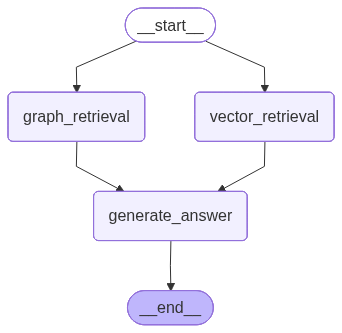

In [52]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [53]:
test_questions = [
    "Who is the CEO of Aurora Holdings?",
    "Which company acquired Beacon Retail Group and why?",
    "Tell me about supply chain challenges faced by these companies",
    "What decisions did Crest Manufacturing make in Q1 and what were the results?",
    "List all the people mentioned across all companies and their roles",
    "Which companies operate in Vietnam?",
]

agent_results = []
for q in test_questions:
    print(f"\n{'=' * 70}")
    print(f"Q: {q}")
    result = agent.invoke({"question": q})
    print(f"A: {result['answer']}")
    agent_results.append(result)

2026-04-05 23:05:09,573 [INFO] graph_rag_lab - Graph retrieval for: Who is the CEO of Aurora Holdings?
2026-04-05 23:05:09,574 [INFO] graph_rag_lab - Vector retrieval for: Who is the CEO of Aurora Holdings?



Q: Who is the CEO of Aurora Holdings?


> Entering new GraphCypherQAChain chain...


2026-04-05 23:05:09,929 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-04-05 23:05:11,365 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generated Cypher:
cypher
MATCH (c:Company {id: 'Aurora Holdings'})-[:CEO_OF]-(p:Person)
RETURN p.id AS ceo

Full Context:
[{'ceo': 'Tran Thi Lan Anh'}]


2026-04-05 23:05:12,663 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

Generated Cypher:
cypher
MATCH (c:Company)-[:OPERATES_IN]-(m:Market {id: 'Vietnam'})
RETURN c.id AS company_id

Full Context:
[]


2026-04-05 23:05:57,461 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



> Finished chain.


2026-04-05 23:05:59,054 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 23:05:59,065 [INFO] graph_rag_lab - Generated answer for: Which companies operate in Vietnam?


A: The context mentions Crest Manufacturing as a company headquartered in Vietnam. However, it does not provide information about any other companies operating in Vietnam. Therefore, based on the provided context, only Crest Manufacturing is identified as operating in Vietnam.


## Step 8: Evaluation — GraphRAG vs. Vector-Only RAG

Compare the GraphRAG agent (with routing) against a **vector-only** baseline.
We use **LLM-as-judge** to score each answer against expected answers on a 1-5 scale.

Hypothesis: GraphRAG should outperform on **relationship** and **decision-result** questions,
while vector search should perform comparably on **semantic/topical** questions.

In [54]:
eval_questions = [
    {
        "question": "Who is the CEO of Aurora Holdings?",
        "expected": "Tran Thi Lan Anh is the CEO of Aurora Holdings.",
        "type": "relationship",
    },
    {
        "question": "Which company buy Beacon Retail Group?",
        "expected": "Aurora Holdings acquired 100% equity in Beacon Retail Group in Q2 2025.",
        "type": "relationship",
    },
    {
        "question": "What was the result of Crest Manufacturing investing in automation in Q1?",
        "expected": "Improved production consistency, reduced error rates, and lower long-term operating costs.",
        "type": "decision-result",
    },
    {
        "question": "Who are the independent directors at Crest Manufacturing?",
        "expected": "James Park and Anna Kovac are the independent directors at Crest Manufacturing.",
        "type": "relationship",
    },
    {
        "question": "What is the relationship between Aurora Holdings and Beacon Retail Group?",
        "expected": "Aurora Holdings acquired 100% equity in Beacon Retail Group to integrate retail into its digital ecosystem.",
        "type": "relationship",
    },
    {
        "question": "Tell me about digital transformation initiatives across these companies",
        "expected": "Beacon Retail initiated e-commerce platform development in Q3. Aurora launched a unified digital commerce ecosystem in Q4.",
        "type": "semantic",
    },
    {
        "question": "What challenges did companies face with supply chains in 2025?",
        "expected": "Crest Manufacturing faced supply chain disruptions for raw materials in Q3 due to global supply constraints and logistical bottlenecks.",
        "type": "semantic",
    },
    {
        "question": "Which companies operate in Vietnam?",
        "expected": "Beacon Retail Group operates in Vietnam and Thailand. Crest Manufacturing is headquartered in Vietnam.",
        "type": "relationship",
    },
]

In [55]:
judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

judge_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are an evaluation judge. Score the answer against the expected answer.

Scale:
1 = Completely wrong or irrelevant
2 = Partially relevant but mostly incorrect
3 = Somewhat correct but missing key details
4 = Mostly correct with minor omissions
5 = Fully correct and comprehensive

Return ONLY the numeric score (1-5), nothing else.""",
        ),
        (
            "human",
            "Question: {question}\nExpected Answer: {expected}\nActual Answer: {answer}",
        ),
    ]
)

judge_chain = judge_prompt | judge_llm | StrOutputParser()

vector_answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful business analyst. Answer the question based only on the provided context. "
            "If the context doesn't contain enough information, say so clearly.",
        ),
        ("human", "Context:\n{context}\n\nQuestion: {question}"),
    ]
)
vector_answer_chain = vector_answer_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0) | StrOutputParser()


eval_results = []
for item in eval_questions:
    q = item["question"]
    logger.info("Evaluating: %s", q[:50])

    graph_rag_result = agent.invoke({"question": q})

    vector_docs = vector_retriever.invoke(q)
    vector_context = "\n\n".join([d.page_content for d in vector_docs])
    vector_answer = vector_answer_chain.invoke({"question": q, "context": vector_context})

    graph_score_raw = judge_chain.invoke(
        {"question": q, "expected": item["expected"], "answer": graph_rag_result["answer"]}
    )
    vector_score_raw = judge_chain.invoke(
        {"question": q, "expected": item["expected"], "answer": vector_answer}
    )

    try:
        graph_score = int(graph_score_raw.strip())
    except ValueError:
        graph_score = 0
    try:
        vector_score = int(vector_score_raw.strip())
    except ValueError:
        vector_score = 0

    eval_results.append(
        {
            "question": q,
            "type": item["type"],
            "graph_rag_answer": graph_rag_result["answer"],
            "graph_rag_score": graph_score,
            "vector_rag_answer": vector_answer,
            "vector_rag_score": vector_score,
        }
    )
    logger.info("  GraphRAG: %d | VectorRAG: %d", graph_score, vector_score)

2026-04-05 23:07:18,545 [INFO] graph_rag_lab - Evaluating: Who is the CEO of Aurora Holdings?
2026-04-05 23:07:18,548 [INFO] graph_rag_lab - Graph retrieval for: Who is the CEO of Aurora Holdings?
2026-04-05 23:07:18,548 [INFO] graph_rag_lab - Vector retrieval for: Who is the CEO of Aurora Holdings?




> Entering new GraphCypherQAChain chain...


2026-04-05 23:07:19,738 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-04-05 23:07:20,760 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generated Cypher:
cypher
MATCH (c:Company {id: 'Aurora Holdings'})-[:CEO_OF]-(p:Person)
RETURN p.id AS ceo

Full Context:
[{'ceo': 'Tran Thi Lan Anh'}]


2026-04-05 23:07:23,225 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-04-05 23:08:21,283 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generated Cypher:
cypher
MATCH (c:Company)-[:OPERATES_IN]-(m:Market {id: 'Vietnam'})
RETURN c.id AS company

Full Context:
[]


2026-04-05 23:08:22,011 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



> Finished chain.


2026-04-05 23:08:23,458 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 23:08:23,462 [INFO] graph_rag_lab - Generated answer for: Which companies operate in Vietnam?
2026-04-05 23:08:23,671 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-04-05 23:08:25,477 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 23:08:26,018 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 23:08:26,565 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-05 23:08:26,569 [INFO] graph_rag_lab -   GraphRAG: 3 | VectorRAG: 3


In [56]:
print(f"\n{'=' * 90}")
print(f"{'EVALUATION RESULTS: GraphRAG vs Vector-Only RAG':^90}")
print(f"{'=' * 90}")
print(f"\n{'Question':<55} {'Type':<16} {'GraphRAG':<10} {'VectorRAG':<10}")
print("-" * 91)

for r in eval_results:
    q_short = (r['question'][:53] + '..') if len(r['question']) > 55 else r['question']
    print(f"{q_short:<55} {r['type']:<16} {r['graph_rag_score']:<10} {r['vector_rag_score']:<10}")

graph_avg = sum(r["graph_rag_score"] for r in eval_results) / len(eval_results)
vector_avg = sum(r["vector_rag_score"] for r in eval_results) / len(eval_results)
print("-" * 91)
print(f"{'AVERAGE':<55} {'':<16} {graph_avg:<10.2f} {vector_avg:<10.2f}")

print(f"\n{'Per-Type Analysis':^90}")
print("-" * 91)
for qtype in sorted(set(r["type"] for r in eval_results)):
    typed = [r for r in eval_results if r["type"] == qtype]
    g_avg = sum(r["graph_rag_score"] for r in typed) / len(typed)
    v_avg = sum(r["vector_rag_score"] for r in typed) / len(typed)
    print(f"  {qtype:<20} GraphRAG avg: {g_avg:.2f}  |  VectorRAG avg: {v_avg:.2f}")


                     EVALUATION RESULTS: GraphRAG vs Vector-Only RAG                      

Question                                                Type             GraphRAG   VectorRAG 
-------------------------------------------------------------------------------------------
Who is the CEO of Aurora Holdings?                      relationship     5          1         
Which company buy Beacon Retail Group?                  relationship     4          1         
What was the result of Crest Manufacturing investing .. decision-result  2          2         
Who are the independent directors at Crest Manufactur.. relationship     5          1         
What is the relationship between Aurora Holdings and .. relationship     5          5         
Tell me about digital transformation initiatives acro.. semantic         2          2         
What challenges did companies face with supply chains.. semantic         5          5         
Which companies operate in Vietnam?                    

In [57]:
for i, r in enumerate(eval_results):
    print(f"\n{'=' * 80}")
    print(f"Q{i + 1}: {r['question']}")
    print(f"\n  GraphRAG (score {r['graph_rag_score']}/5):")
    print(f"    {r['graph_rag_answer'][:300]}")
    print(f"\n  VectorRAG (score {r['vector_rag_score']}/5):")
    print(f"    {r['vector_rag_answer'][:300]}")


Q1: Who is the CEO of Aurora Holdings?

  GraphRAG (score 5/5):
    The CEO of Aurora Holdings is Tran Thi Lan Anh.

  VectorRAG (score 1/5):
    The provided context does not contain information about the CEO of Aurora Holdings.

Q2: Which company buy Beacon Retail Group?

  GraphRAG (score 4/5):
    Aurora Holdings bought Beacon Retail Group.

  VectorRAG (score 1/5):
    The provided context does not contain any information regarding a company buying Beacon Retail Group.

Q3: What was the result of Crest Manufacturing investing in automation in Q1?

  GraphRAG (score 2/5):
    The result of Crest Manufacturing investing in automation in Q1 was a temporary decline in both operating and net profits due to the impact on production output. The company implemented contingency measures, such as adjusting production schedules and prioritizing high-value orders, in response to th

  VectorRAG (score 2/5):
    The result of Crest Manufacturing investing in automation in Q1 was a temporary d